In [1]:
from hyppo.discrim import DiscrimOneSample
import numpy as np
from glob import glob
import pickle
import os.path as op
import pandas as pd
from hyppo.discrim import DiscrimOneSample, DiscrimTwoSample

In [19]:
results_path = '/global/homes/m/mphagen/functional-connectivity/connectome-comparison/results'

date_string = '2025-12-10'
with open(glob(op.join(results_path, 'xcpd', f'{date_string}*lassoBIC*pkl'))[0],   'rb') as f:
        xcpd_lasso_dict = pickle.load(f)

with open(glob(op.join(results_path, 'MSMAll', f'{date_string}*lassoBIC*pkl'))[0],   'rb') as f:
        msmall_lasso_dict = pickle.load(f)


with open(glob(op.join(results_path, 'MSMAll', f'{date_string}*correlation*pkl'))[0],   'rb') as f:
        msmall_pearson_dict = pickle.load(f)

with open(glob(op.join(results_path, 'xcpd', f'{date_string}*correlation*pkl'))[0],   'rb') as f:
        xcpd_pearson_dict = pickle.load(f)

with open(glob(op.join(results_path, 'xcpd', f'{date_string}*uoi*pkl'))[0],   'rb') as f:
        xcpd_uoi_dict = pickle.load(f)

with open(glob(op.join(results_path, 'MSMAll', f'{date_string}*uoi*pkl'))[0],   'rb') as f:
        msmall_uoi_dict = pickle.load(f)

    

In [20]:
def one_samp_discrim(fc_dict): 
    ses_1 = np.ndarray(shape=(len(fc_dict.keys()),10000), dtype=float)
    ses_2 = np.ndarray(shape=(len(fc_dict.keys()),10000), dtype=float)

    y = list() 

    for num, key in enumerate(fc_dict.keys()): 
        ses_1[num] = np.array(fc_dict[key]['ses-1']).ravel()
        ses_2[num] = np.array(fc_dict[key]['ses-2']).ravel()

        y.append(num) 
    y = np.array((y + y )) 

    x = np.append(ses_1, ses_2, axis=0) 
    stat = DiscrimOneSample().test(x, y) 
    return stat 
    

In [21]:
def two_samp_discrim(x1_fc_dict, x2_fc_dict): 
    x1_ses_1 = np.ndarray(shape=(len(x1_fc_dict.keys()),10000), dtype=float)
    x1_ses_2 = np.ndarray(shape=(len(x1_fc_dict.keys()),10000), dtype=float)

    x2_ses_1 = np.ndarray(shape=(len(x1_fc_dict.keys()),10000), dtype=float)
    x2_ses_2 = np.ndarray(shape=(len(x1_fc_dict.keys()),10000), dtype=float)

    y = list() 

    for num, key in enumerate(x1_fc_dict.keys()): 
        x1_ses_1[num] = np.array(x1_fc_dict[key]['ses-1']).ravel()
        x1_ses_2[num] = np.array(x1_fc_dict[key]['ses-2']).ravel()

        x2_ses_1[num] = np.array(x2_fc_dict[key]['ses-1']).ravel()
        x2_ses_2[num] = np.array(x2_fc_dict[key]['ses-2']).ravel()

        y.append(num) 
    y = np.array((y+y)) 

    
    x_1 = np.append(x1_ses_1, x1_ses_2, axis=0) 

    x_2 = np.append(x2_ses_1, x2_ses_2, axis=0) 

    
    stat = DiscrimTwoSample().test(x_1, x_2, y) 
    return stat 

In [5]:
pearson_proc_discrim = two_samp_discrim(msmall_pearson_dict, xcpd_pearson_dict) 

In [6]:
pearson_proc_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.7638980263157894), d2=np.float64(0.952576754385965), pvalue=0.001)

In [7]:
lasso_proc_discrim = two_samp_discrim(msmall_lasso_dict, xcpd_lasso_dict) 

In [8]:
lasso_proc_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.9725173574584473), d2=np.float64(0.8646907216494847), pvalue=0.001)

In [9]:
uoi_proc_discrim = two_samp_discrim(msmall_uoi_dict, xcpd_uoi_dict) 

In [10]:
uoi_proc_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.9618398905954134), d2=np.float64(0.8646381232905532), pvalue=0.001)

MSMALL more discriminable 

In [11]:
msmall_model_discrim = two_samp_discrim(msmall_uoi_dict, msmall_lasso_dict) 

In [12]:
msmall_model_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.9618398905954134), d2=np.float64(0.9725173574584473), pvalue=np.float64(0.4269129129129129))

In [13]:
xcpd_model_discrim = two_samp_discrim(xcpd_uoi_dict, xcpd_lasso_dict) 

In [14]:
xcpd_model_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.8646381232905532), d2=np.float64(0.8646907216494847), pvalue=np.float64(1.0))

In [15]:
xcpd_pearson_uoi_discrim = two_samp_discrim(xcpd_uoi_dict, xcpd_pearson_dict) 

In [16]:
xcpd_pearson_uoi_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.8646381232905532), d2=np.float64(0.9506890385019987), pvalue=0.001)

sanity check - look at ses-1 by ses-1, ses-2 by ses-2 to confirm bound by 1. 

In [25]:
xcpd_pearson_lasso_discrim = two_samp_discrim(xcpd_lasso_dict, xcpd_pearson_dict) 

In [26]:
xcpd_pearson_lasso_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.8646907216494847), d2=np.float64(0.9506890385019987), pvalue=0.001)

In [22]:
temp_msmall_uoi_dict = {} 

In [23]:
[temp_msmall_uoi_dict.update({ii: msmall_uoi_dict[ii]}) for ii in msmall_uoi_dict.keys() if ii not in ['sub-579665', 'sub-454140']]
msmall_pearson_uoi_discrim = two_samp_discrim(temp_msmall_uoi_dict, msmall_pearson_dict) 

In [24]:
msmall_pearson_uoi_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.9638706140350877), d2=np.float64(0.7638980263157894), pvalue=0.001)

In [29]:
temp_msmall_lasso_dict = {} 

In [31]:
[temp_msmall_lasso_dict.update({ii: msmall_lasso_dict[ii]}) for ii in msmall_lasso_dict.keys() if ii not in ['sub-579665', 'sub-454140']]

msmall_pearson_lasso_discrim = two_samp_discrim(temp_msmall_lasso_dict, msmall_pearson_dict) 

In [32]:
msmall_pearson_lasso_discrim

DiscrimTwoSampleTestOutput(d1=np.float64(0.9746984649122806), d2=np.float64(0.7638980263157894), pvalue=0.001)

In [38]:
xcpd_pearson_stat = one_samp_discrim(xcpd_pearson_dict).stat

In [39]:
msmall_pearson_stat = one_samp_discrim(msmall_pearson_dict).stat

In [40]:
xcpd_lasso_stat = one_samp_discrim(xcpd_lasso_dict).stat

In [41]:
msmall_lasso_stat = one_samp_discrim(msmall_lasso_dict).stat

In [42]:
xcpd_uoi_stat = one_samp_discrim(xcpd_uoi_dict).stat

In [43]:
msmall_uoi_stat = one_samp_discrim(msmall_uoi_dict).stat

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
sns.set_palette('deep') 


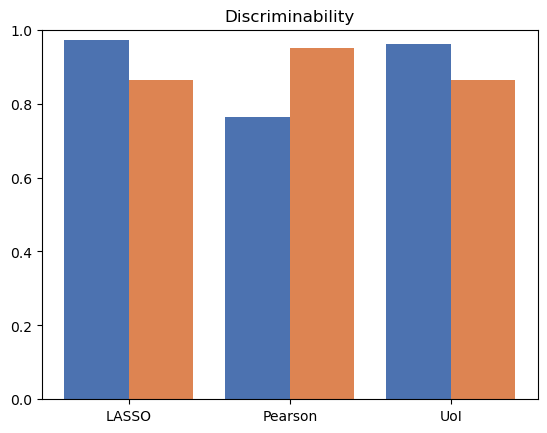

In [95]:
x = np.array([1,2, 3]) 
plt.bar(x+.2, [xcpd_lasso_stat, xcpd_pearson_stat, xcpd_uoi_stat], width=.4, color=sns.color_palette()[1])
plt.bar(x-.2, [msmall_lasso_stat,msmall_pearson_stat, msmall_uoi_stat], width=.4, color=sns.color_palette()[0])

h, col = .01, 'k'

# plt.legend(['XCPD', 'MinProc'], title='Processing Pipeline')

# ###btwn proc type significance bars  
# btwn_proc_offset  = .98
# plt.plot([x[0] -.2, x[0]-.2, x[0]+.2, x[0]+.2], [btwn_proc_offset, btwn_proc_offset+h, btwn_proc_offset+h, btwn_proc_offset], lw=1.5, c='black', alpha=.5)
# plt.plot([x[1] -.2, x[1]-.2, x[1]+.2, x[1]+.2], [btwn_proc_offset, btwn_proc_offset+h, btwn_proc_offset+h, btwn_proc_offset], lw=1.5, c='black')
# plt.plot([x[2] -.2, x[2]-.2, x[2]+.2, x[2]+.2], [btwn_proc_offset, btwn_proc_offset+h, btwn_proc_offset+h, btwn_proc_offset], lw=1.5, c='black')

# ###btwen model sign values 
# btwn_model_offset  = 1
# plt.plot([x[0] -.2, x[0]-.2, x[1]-.2, x[1]-.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')
# btwn_model_offset  = 1.02
# plt.plot([x[0] +.2, x[0]+.2, x[1]+.2, x[1]+.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')

# # plt.plot([x[1] -.2, x[1]-.2, x[1]+.2, x[1]+.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')
# # plt.plot([x[2] -.2, x[2]-.2, x[2]+.2, x[2]+.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')
plt.title('Discriminability')
plt.xticks(x, ['LASSO', 'Pearson', 'UoI']) 
plt.ylim([0, 1])
plt.savefig('discriminability.png')

(0.5, 1.1)

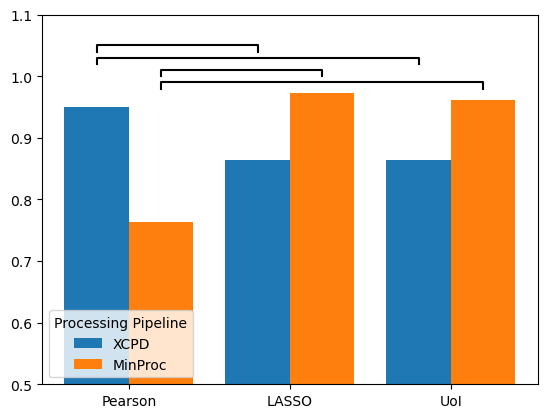

In [67]:

x = np.array([1,2, 3]) 
plt.bar(x-.2, [xcpd_pearson_stat, xcpd_lasso_stat, xcpd_uoi_stat], width=.4, color=sns.color_palette()[0])
plt.bar(x+.2, [msmall_pearson_stat, msmall_lasso_stat, msmall_uoi_stat], width=.4, color=sns.color_palette()[1])

h, col = .01, 'k'

plt.legend(['XCPD', 'MinProc'], title='Processing Pipeline')

###btwen model sign values 
btwn_model_offset  = 1.04
plt.plot([x[0] -.2, x[0]-.2, x[1]-.2, x[1]-.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')
btwn_model_offset  = 1
plt.plot([x[0] +.2, x[0]+.2, x[1]+.2, x[1]+.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')
btwn_model_offset  = 1.02

plt.plot([x[0] -.2, x[0]-.2, x[2]-.2, x[2]-.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')
btwn_model_offset  = .98
plt.plot([x[0] +.2, x[0]+.2, x[2]+.2, x[2]+.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')

# plt.plot([x[1] -.2, x[1]-.2, x[1]+.2, x[1]+.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')
# plt.plot([x[2] -.2, x[2]-.2, x[2]+.2, x[2]+.2], [btwn_model_offset, btwn_model_offset+h, btwn_model_offset+h, btwn_model_offset], lw=1.5, c='black')

plt.xticks(x, ['Pearson', 'LASSO', 'UoI']) 
plt.ylim([.5, 1.1])

In [ ]:
msmall_lasso_dict

In [88]:
x1_ses_1 = np.ndarray(shape=(len(msmall_lasso_dict.keys()),10000), dtype=float)
for num, key in enumerate(msmall_lasso_dict.keys()): 
        x1_ses_1[num] = np.array(msmall_lasso_dict[key]['ses-1']).ravel()




In [85]:
from pingouin import multivariate_normality


In [105]:
sum(sum(np.isnan(x1_ses_1)) ) 

np.int64(0)

In [90]:
multivariate_normality(x1_ses_1) 
#too high dimensional, or insanely non-normal?? 

HZResults(hz=392, pval=np.float64(nan), normal=False)

In [96]:
pearson_ar = np.ndarray(shape=(len(msmall_pearson_dict.keys()),10000), dtype=float)
for num, key in enumerate(msmall_pearson_dict.keys()): 
        pearson_ar[num] = np.array(msmall_pearson_dict[key]['ses-1']).ravel()




In [97]:
multivariate_normality(pearson_ar) 


HZResults(hz=384, pval=np.float64(nan), normal=False)

In [98]:
pearson_ar = np.ndarray(shape=(len(xcpd_pearson_dict.keys()),10000), dtype=float)
for num, key in enumerate(xcpd_pearson_dict.keys()): 
        pearson_ar[num] = np.array(xcpd_pearson_dict[key]['ses-1']).ravel()




In [99]:
multivariate_normality(pearson_ar) 


HZResults(hz=392, pval=np.float64(nan), normal=False)

In [106]:
xcpd_lasso_ar = np.ndarray(shape=(len(xcpd_lasso_dict.keys()),10000), dtype=float)
for num, key in enumerate(xcpd_lasso_dict.keys()): 
        xcpd_lasso_ar[num] = np.array(xcpd_lasso_dict[key]['ses-1']).ravel()



In [108]:
multivariate_normality(xcpd_lasso_ar) 

HZResults(hz=392, pval=np.float64(nan), normal=False)